In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from pathlib import Path

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
TODAY    = pd.Timestamp.today().normalize()

plt.rcParams.update({
    'figure.dpi':        120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

COLORS = {
    'primary': '#3b82f6',
    'success': '#22c55e',
    'danger':  '#ef4444',
    'warning': '#f97316',
    'purple':  '#8b5cf6',
    'gray':    '#6b7280',
}

PLAN_COLORS = {
    'starter':    '#ef4444',
    'growth':     '#f97316',
    'pro':        '#eab308',
    'enterprise': '#22c55e',
}

#  Load data
subs      = pd.read_csv(DATA_DIR / 'subscriptions.csv',   parse_dates=['signup_date','churn_date'])
events    = pd.read_csv(DATA_DIR / 'product_events.csv',  parse_dates=['event_date'])
leads     = pd.read_csv(DATA_DIR / 'leads.csv',           parse_dates=['created_date','converted_date'])
campaigns = pd.read_csv(DATA_DIR / 'email_campaigns.csv', parse_dates=['send_date'])
sends     = pd.read_csv(DATA_DIR / 'email_sends.csv',     parse_dates=['send_date'])

#  Quick sanity check
print(f"Data loaded | subs: {len(subs):,} | events: {len(events):,} | leads: {len(leads):,}")

print(f"Date range  | {subs['signup_date'].min().date()} → {TODAY.date()}")

Data loaded | subs: 500 | events: 212,110 | leads: 1,700
Date range  | 2025-04-20 → 2026-04-28


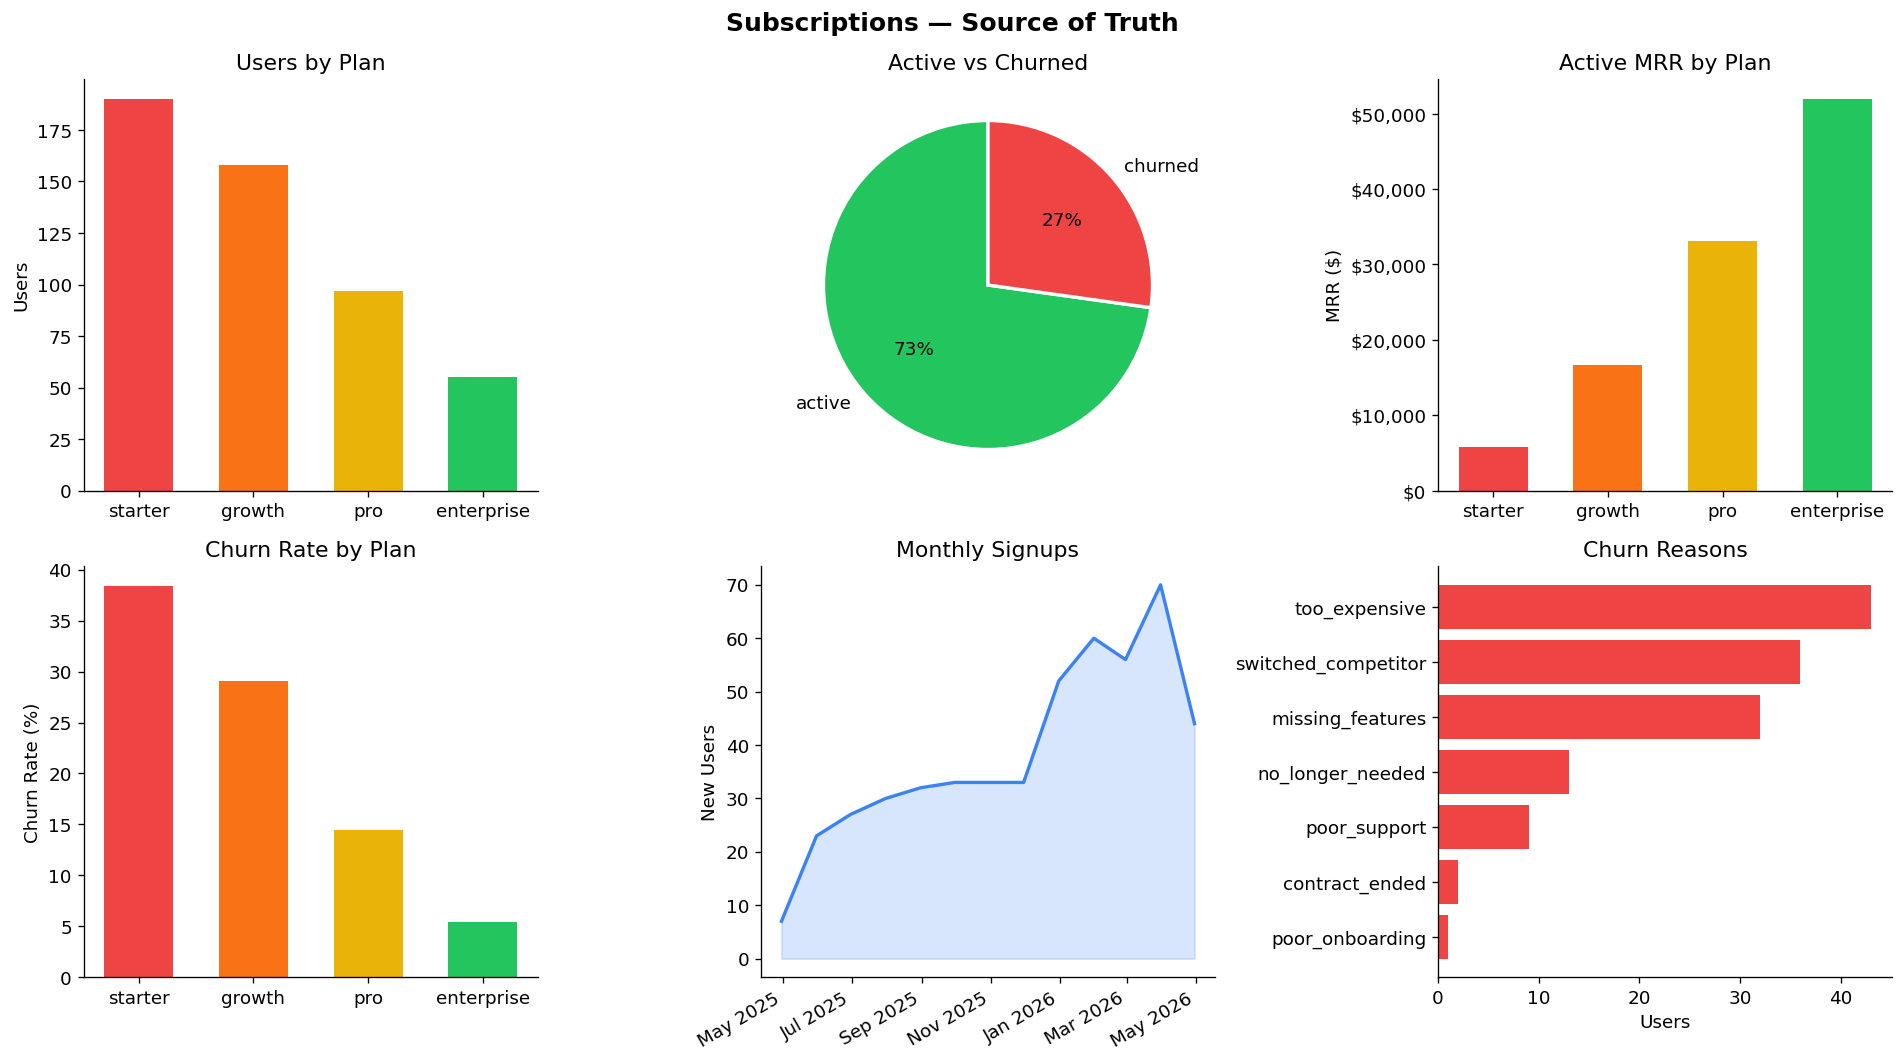

Users: 500 | Active: 73%
MRR  : $107,486 | Avg/user: $295


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Subscriptions — Source of Truth', fontsize=15, fontweight='bold')

PLAN_ORDER = ['starter','growth','pro','enterprise']

# 1. Plan distribution
ax = axes[0, 0]
plan_counts = subs['plan'].value_counts().reindex(PLAN_ORDER, fill_value=0)
bars = ax.bar(plan_counts.index, plan_counts.values,
              color=[PLAN_COLORS[p] for p in plan_counts.index], width=0.6)
ax.set_title('Users by Plan')
ax.set_ylabel('Users')

# 2. Active vs churned
ax = axes[0, 1]
status_counts = subs['status'].value_counts()
ax.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=[COLORS['success'], COLORS['danger']],
    autopct='%1.0f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
ax.set_title('Active vs Churned')

# 3. MRR by plan
ax = axes[0, 2]
mrr_by_plan = (
    subs[subs['status'] == 'active']
    .groupby('plan')['mrr'].sum()
    .reindex(PLAN_ORDER, fill_value=0)
)
ax.bar(mrr_by_plan.index, mrr_by_plan.values,
       color=[PLAN_COLORS[p] for p in mrr_by_plan.index], width=0.6)
ax.set_title('Active MRR by Plan')
ax.set_ylabel('MRR ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 4. Churn rate by plan
ax = axes[1, 0]
churn_rate = (
    subs.groupby('plan')['status']
    .apply(lambda x: (x == 'churned').mean() * 100)
    .reindex(PLAN_ORDER, fill_value=0)
)
ax.bar(churn_rate.index, churn_rate.values,
       color=[PLAN_COLORS[p] for p in churn_rate.index], width=0.6)
ax.set_title('Churn Rate by Plan')
ax.set_ylabel('Churn Rate (%)')

# 5. Signups over time
ax = axes[1, 1]
monthly_signups = (
    subs.set_index('signup_date')
    .resample('ME')['user_id'].count()
)
ax.plot(monthly_signups.index, monthly_signups.values,
        color=COLORS['primary'], lw=2)
ax.fill_between(monthly_signups.index, monthly_signups.values,
                color=COLORS['primary'], alpha=0.2)
ax.set_title('Monthly Signups')
ax.set_ylabel('New Users')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# 6. Churn reasons
ax = axes[1, 2]
reasons = subs['churn_reason'].dropna().value_counts()
ax.barh(reasons.index, reasons.values, color=COLORS['danger'])
ax.set_title('Churn Reasons')
ax.set_xlabel('Users')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Key stats (minimal)
active = subs[subs['status'] == 'active']

print(f"Users: {len(subs):,} | Active: {len(active)/len(subs):.0%}")
print(f"MRR  : ${active['mrr'].sum():,.0f} | Avg/user: ${active['mrr'].mean():,.0f}")

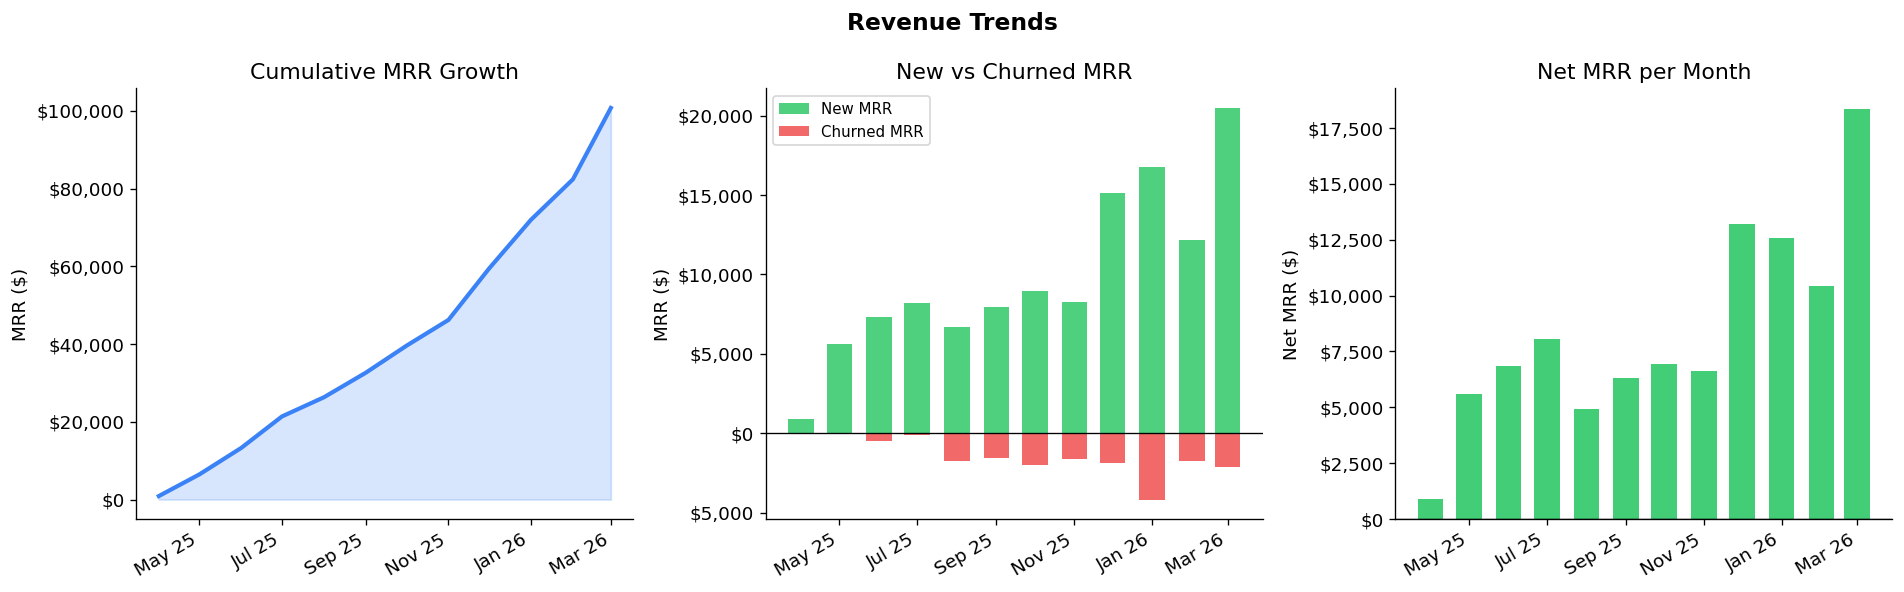


MRR summary
Final MRR   : $100,719
Best month  : Mar 2026
Worst month : Apr 2025


In [8]:
# Monthly MRR waterfall
monthly_new = (
    subs.assign(month=subs['signup_date'].dt.to_period('M').dt.start_time)
    .groupby('month')['mrr'].sum()
    .reset_index(name='new_mrr')
)
monthly_churned = (
    subs[subs['status'] == 'churned']
    .assign(month=lambda df: df['churn_date'].dt.to_period('M').dt.start_time)
    .groupby('month')['mrr'].sum()
    .reset_index(name='churned_mrr')
)
mrr = monthly_new.merge(monthly_churned, on='month', how='left').fillna(0)
mrr['net_mrr']        = mrr['new_mrr'] - mrr['churned_mrr']
mrr['cumulative_mrr'] = mrr['net_mrr'].cumsum()
mrr = mrr[mrr['month'] < TODAY.to_period('M').to_timestamp()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Revenue Trends', fontsize=14, fontweight='bold')

# Cumulative MRR
ax = axes[0]
ax.fill_between(mrr['month'], mrr['cumulative_mrr'],
                color=COLORS['primary'], alpha=0.2)
ax.plot(mrr['month'], mrr['cumulative_mrr'],
        color=COLORS['primary'], lw=2.5)
ax.set_title('Cumulative MRR Growth')
ax.set_ylabel('MRR ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# New vs churned MRR
ax = axes[1]
ax.bar(mrr['month'], mrr['new_mrr'],
       color=COLORS['success'], alpha=0.8, label='New MRR', width=20)
ax.bar(mrr['month'], -mrr['churned_mrr'],
       color=COLORS['danger'], alpha=0.8, label='Churned MRR', width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('New vs Churned MRR')
ax.set_ylabel('MRR ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${abs(x):,.0f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
ax.legend(fontsize=9)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Net MRR
ax = axes[2]
colors_net = [COLORS['success'] if v >= 0 else COLORS['danger'] for v in mrr['net_mrr']]
ax.bar(mrr['month'], mrr['net_mrr'], color=colors_net, alpha=0.85, width=20)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Net MRR per Month')
ax.set_ylabel('Net MRR ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print("\nMRR summary")
print(f"Final MRR   : ${mrr['cumulative_mrr'].iloc[-1]:,.0f}")
print(f"Best month  : {mrr.loc[mrr['new_mrr'].idxmax(), 'month']:%b %Y}")
print(f"Worst month : {mrr.loc[mrr['net_mrr'].idxmin(), 'month']:%b %Y}")

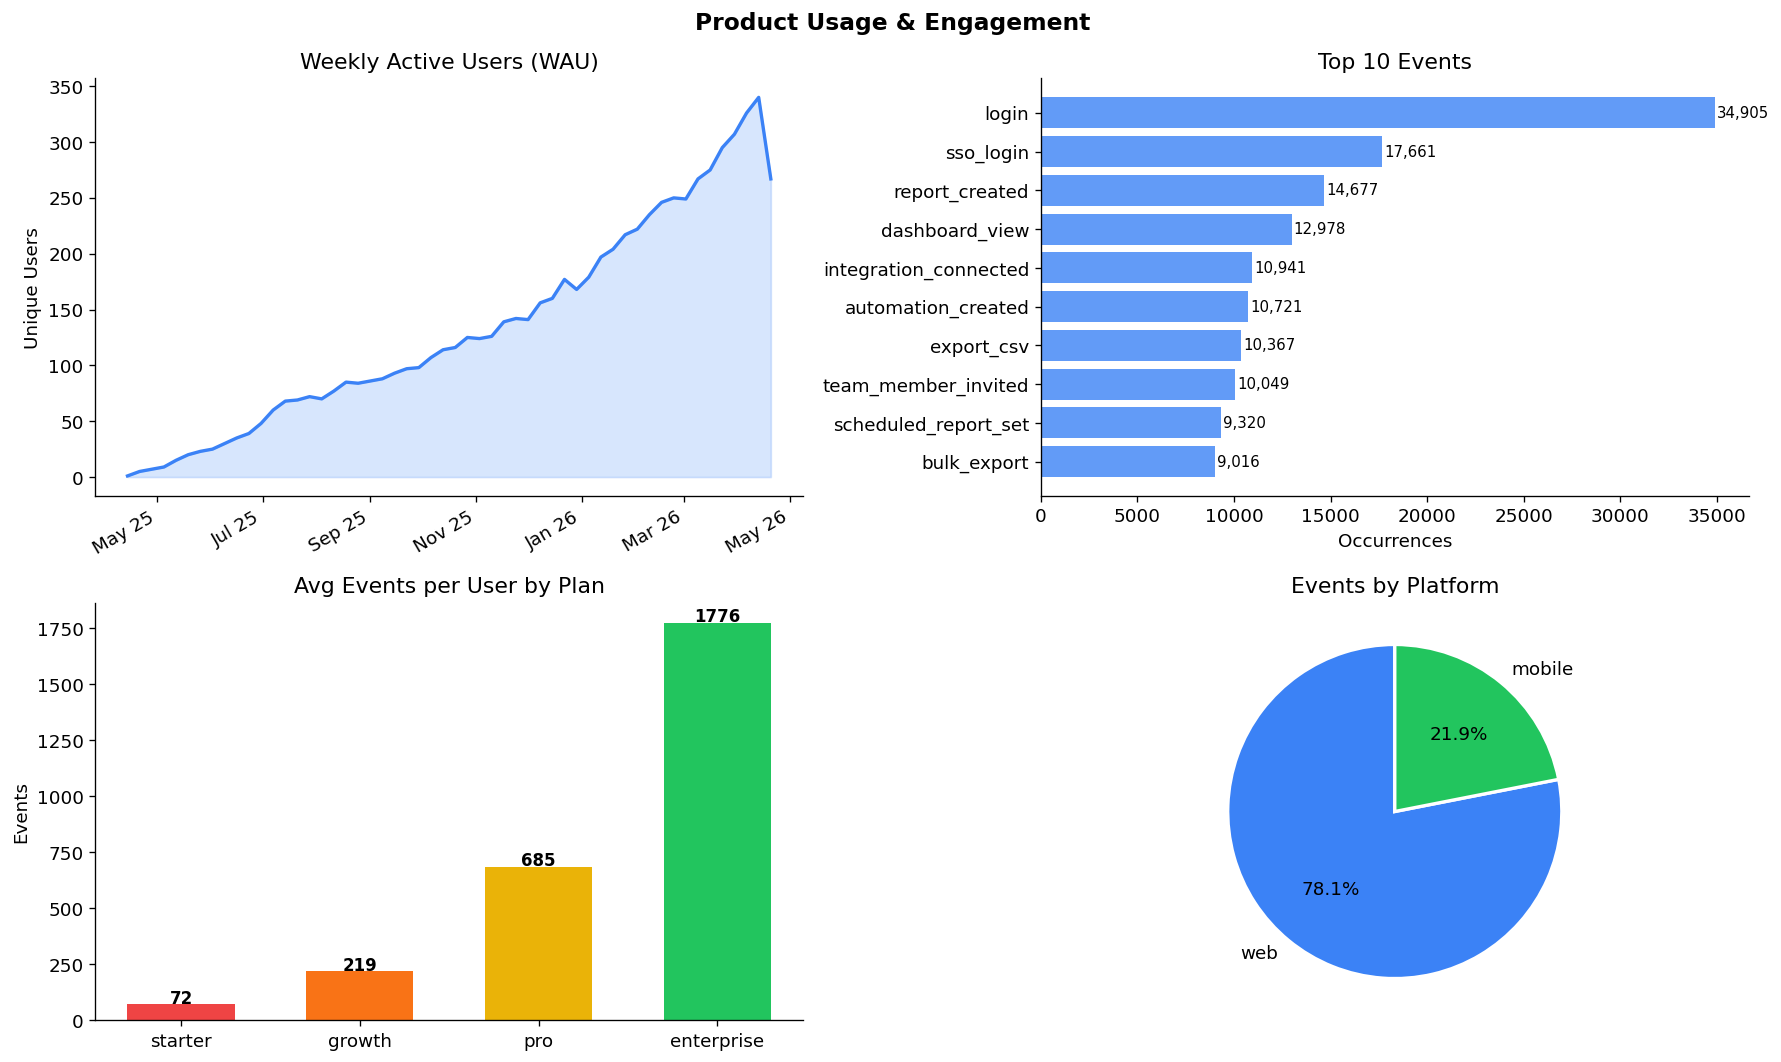


Engagement summary
Users        : 497
Avg events   : 427/user
Peak WAU     : 340
Latest WAU   : 267
Top event    : login


In [9]:
# WAU + event breakdown
weekly_wau = (
    events
    .assign(week=lambda df: df['event_date'].dt.to_period('W').dt.start_time)
    .groupby('week')['user_id'].nunique()
    .reset_index(name='wau')
)
weekly_wau = weekly_wau[weekly_wau['week'] < TODAY - pd.Timedelta(days=TODAY.weekday())]

event_counts = events['event_name'].value_counts().head(10)

events_by_platform = events['platform'].value_counts()

# Events per user by plan
events_with_plan = events.merge(subs[['user_id','plan','status']], on='user_id', how='left')
events_per_user  = (
    events.merge(subs[['user_id','plan']], on='user_id', how='left')
    .groupby(['plan','user_id']).size()
    .groupby('plan').mean()
    .reindex(['starter','growth','pro','enterprise'])
)
    

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Product Usage & Engagement', fontsize=14, fontweight='bold')

# WAU trend
ax = axes[0, 0]
ax.fill_between(weekly_wau['week'], weekly_wau['wau'],
                color=COLORS['primary'], alpha=0.2)
ax.plot(weekly_wau['week'], weekly_wau['wau'],
        color=COLORS['primary'], lw=2)
ax.set_title('Weekly Active Users (WAU)')
ax.set_ylabel('Unique Users')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Top events
ax = axes[0, 1]
ax.barh(event_counts.index, event_counts.values,
        color=COLORS['primary'], alpha=0.8)
ax.set_title('Top 10 Events')
ax.set_xlabel('Occurrences')
ax.invert_yaxis()
for i, val in enumerate(event_counts.values):
    ax.text(val + 100, i, f'{val:,}', va='center', fontsize=9)

# Events per user by plan
ax = axes[1, 0]
bars = ax.bar(events_per_user.index, events_per_user.values,
              color=[PLAN_COLORS[p] for p in events_per_user.index], width=0.6)
ax.set_title('Avg Events per User by Plan')
ax.set_ylabel('Events')
for bar, val in zip(bars, events_per_user.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{val:.0f}', ha='center', fontsize=10, fontweight='bold')

# Platform split
ax = axes[1, 1]
ax.pie(events_by_platform.values,
       labels     = events_by_platform.index,
       colors     = list(COLORS.values())[:len(events_by_platform)],
       autopct    = '%1.1f%%',
       startangle = 90,
       wedgeprops = dict(edgecolor='white', linewidth=2))
ax.set_title('Events by Platform')

plt.tight_layout()
plt.show()

print("\nEngagement summary")
print(f"Users        : {events['user_id'].nunique():,}")
print(f"Avg events   : {len(events)/events['user_id'].nunique():.0f}/user")
print(f"Peak WAU     : {weekly_wau['wau'].max():,}")
print(f"Latest WAU   : {weekly_wau['wau'].iloc[-1]:,}")
print(f"Top event    : {event_counts.index[0]}")

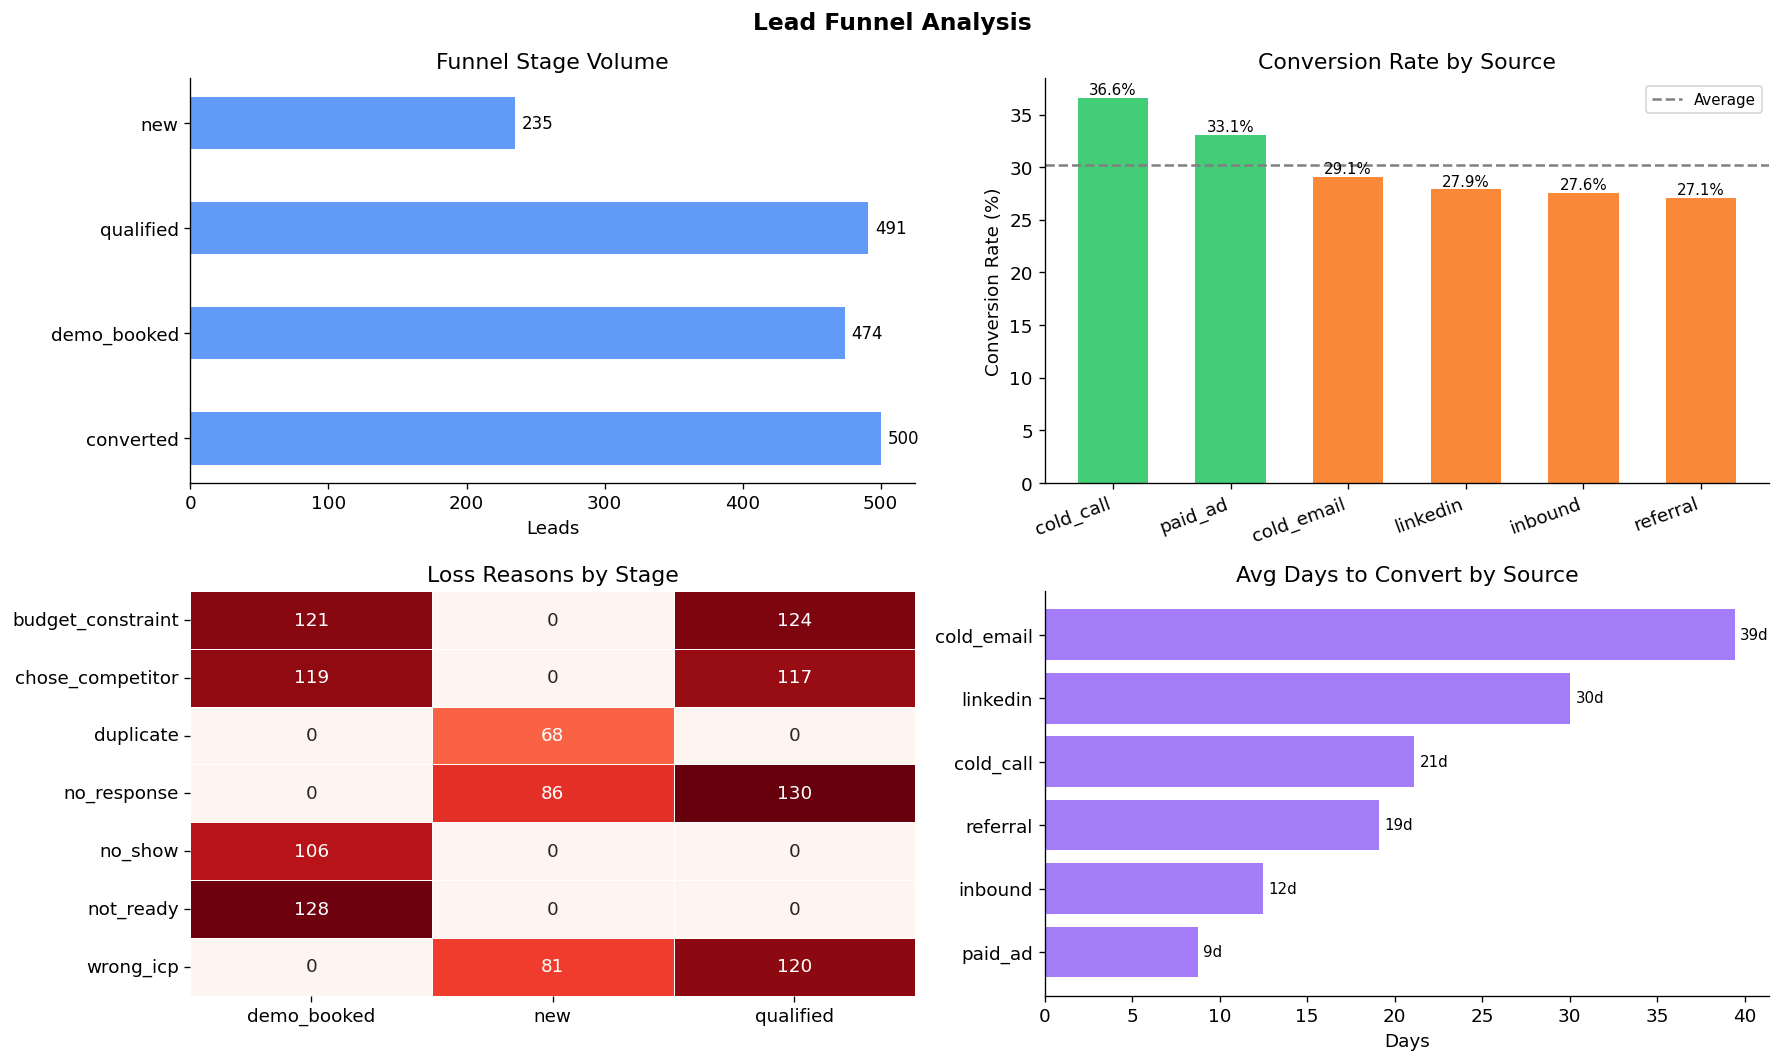


 Funnel summary
Leads        : 1,700
Conversion   : 29.4%
Best source  : cold_call
Fastest      : paid_ad


In [10]:
#Funnel + source analysis
stage_order  = ['new', 'qualified', 'demo_booked', 'converted']
stage_counts = leads['stage'].value_counts().reindex(stage_order).fillna(0)

conv_by_source = (
    leads.assign(is_converted=leads['stage'] == 'converted')
    .groupby('source')
    .agg(
        total     = ('stage', 'size'),
        converted = ('is_converted', 'sum'),
        conv_rate = ('is_converted', 'mean')
    )
)

conv_by_source['conv_rate'] *= 100
conv_by_source = conv_by_source.sort_values('conv_rate', ascending=False)
loss_by_stage = (
    leads[leads['stage'] != 'converted']
    .groupby(['stage','loss_reason']).size()
    .reset_index(name='count')
    .sort_values(['stage','count'], ascending=[True, False])
)

time_to_conv = (
    leads[leads['stage'] == 'converted']
    .assign(days=lambda df: (df['converted_date'] - df['created_date']).dt.days)
    .groupby('source')['days'].mean().sort_values()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Lead Funnel Analysis', fontsize=14, fontweight='bold')

# Funnel
ax = axes[0, 0]
bars = ax.barh(stage_counts.index[::-1], stage_counts.values[::-1],
               color=COLORS['primary'], alpha=0.8, height=0.5)
ax.set_title('Funnel Stage Volume')
ax.set_xlabel('Leads')
for bar, val in zip(bars, stage_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=10)

# Conversion by source
ax = axes[0, 1]
colors_src = [COLORS['success'] if v > conv_by_source['conv_rate'].mean()
              else COLORS['warning'] for v in conv_by_source['conv_rate']]
bars = ax.bar(conv_by_source.index, conv_by_source['conv_rate'],
              color=colors_src, width=0.6, alpha=0.85)
ax.axhline(conv_by_source['conv_rate'].mean(), color='gray',
           linestyle='--', lw=1.5, label='Average')
ax.set_title('Conversion Rate by Source')
ax.set_ylabel('Conversion Rate (%)')
ax.legend(fontsize=9)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')
for bar, val in zip(bars, conv_by_source['conv_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9)

# Loss reasons heatmap
ax = axes[1, 0]
pivot = loss_by_stage.pivot(index='loss_reason', columns='stage', values='count').fillna(0)
sns.heatmap(pivot, ax=ax, cmap='Reds', annot=True, fmt='.0f',
            linewidths=0.5, cbar=False)
ax.set_title('Loss Reasons by Stage')
ax.set_xlabel('')
ax.set_ylabel('')

# Time to convert
ax = axes[1, 1]
ax.barh(time_to_conv.index, time_to_conv.values,
        color=COLORS['purple'], alpha=0.8)
ax.set_title('Avg Days to Convert by Source')
ax.set_xlabel('Days')
for i, val in enumerate(time_to_conv.values):
    ax.text(val + 0.3, i, f'{val:.0f}d', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n Funnel summary")
total = len(leads)
conv  = (leads['stage'] == 'converted').sum()

print(f"Leads        : {total:,}")
print(f"Conversion   : {conv/total*100:.1f}%")
print(f"Best source  : {conv_by_source['conv_rate'].idxmax()}")
print(f"Fastest      : {time_to_conv.idxmin()}")

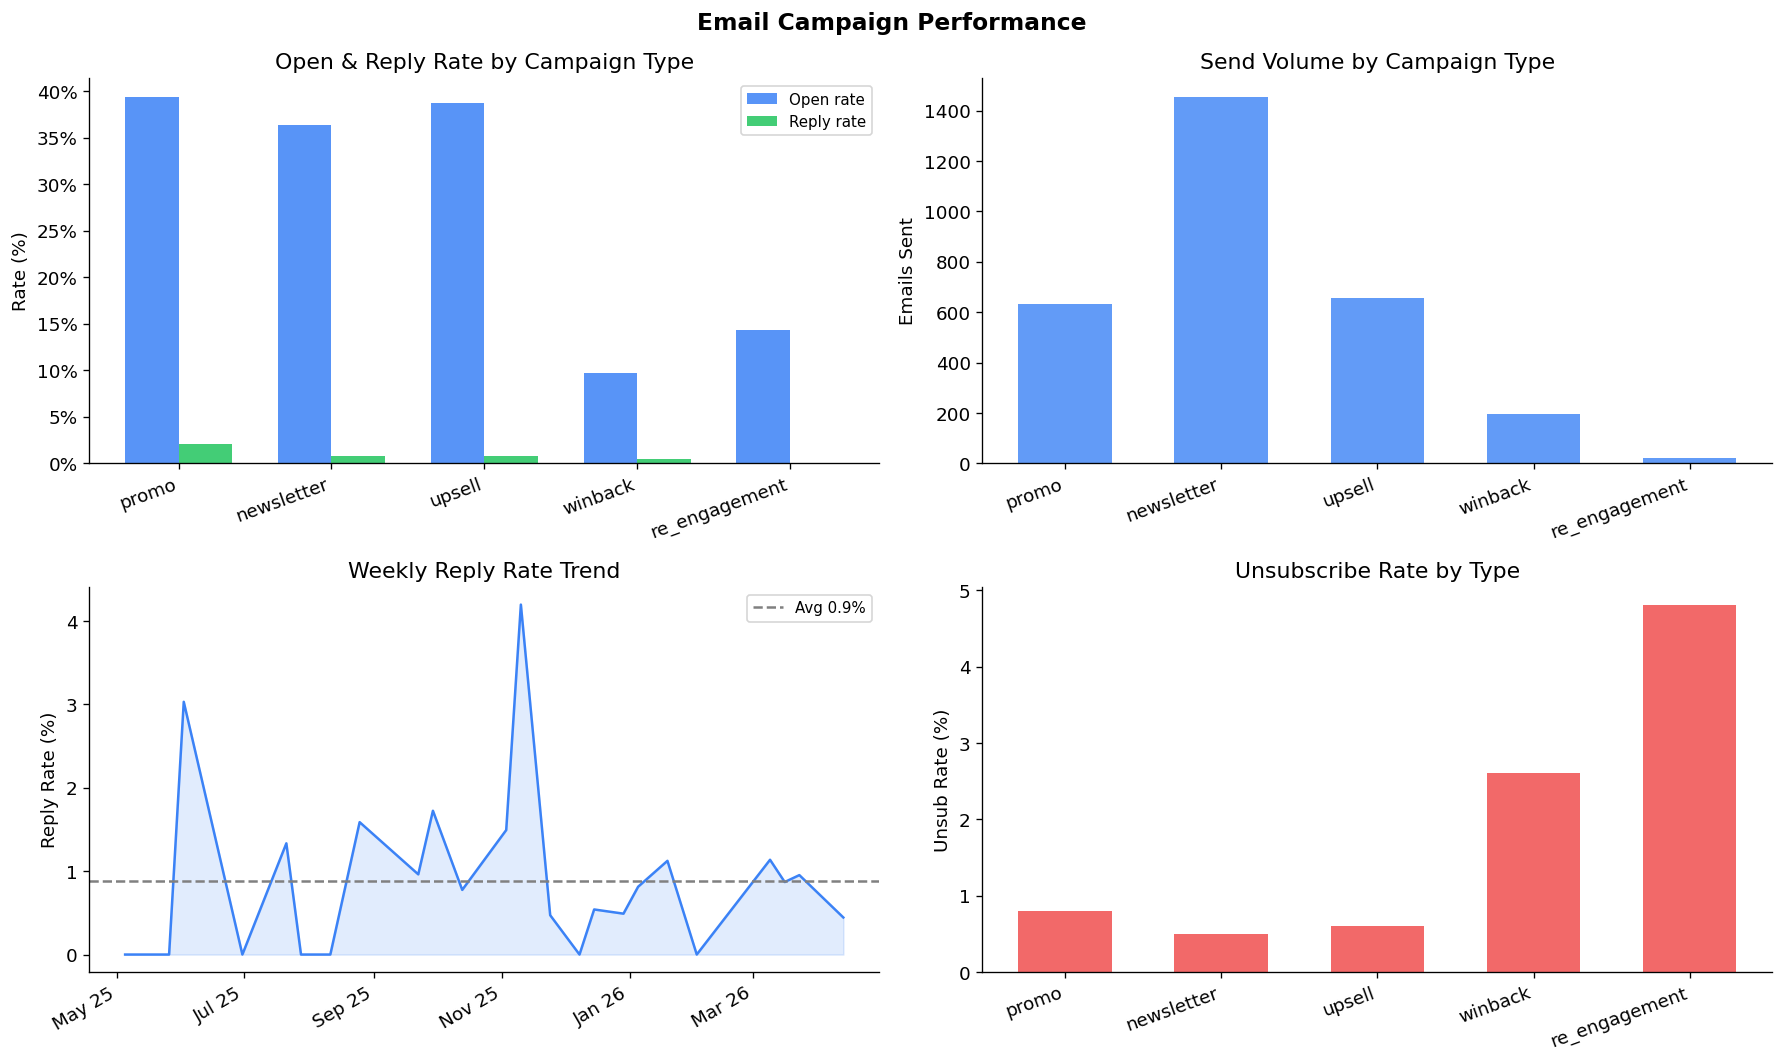


Campaign summary
               sends  open_rate  reply_rate  unsub_rate
campaign_type                                          
promo            634      0.394       0.021       0.008
newsletter      1455      0.364       0.008       0.005
upsell           656      0.387       0.008       0.006
winback          196      0.097       0.005       0.026
re_engagement     21      0.143       0.000       0.048


In [11]:
# Campaign performance 
perf = (
    sends.merge(
        campaigns[['campaign_id','campaign_type']],
        on='campaign_id',
        how='left'
    )
    .groupby('campaign_type')
    .agg(
        sends       = ('send_id',      'count'),
        open_rate   = ('opened',       'mean'),
        click_rate  = ('clicked',      'mean'),
        reply_rate  = ('replied',      'mean'),
        unsub_rate  = ('unsubscribed', 'mean'),
    )
    .round(3)
    .sort_values('reply_rate', ascending=False)
)

# Reply rate over time
weekly_reply = (
    sends
    .assign(week=lambda df: df['send_date'].dt.to_period('W').dt.start_time)
    .groupby('week')
    .agg(reply_rate=('replied','mean'), total_sent=('send_id','count'))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Email Campaign Performance', fontsize=14, fontweight='bold')

# Open vs reply rate by type
ax = axes[0, 0]
x    = np.arange(len(perf))
w    = 0.35
ax.bar(x - w/2, perf['open_rate']  * 100, w, label='Open rate',  color=COLORS['primary'], alpha=0.85)
ax.bar(x + w/2, perf['reply_rate'] * 100, w, label='Reply rate', color=COLORS['success'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(perf.index, rotation=20, ha='right')
ax.set_title('Open & Reply Rate by Campaign Type')
ax.set_ylabel('Rate (%)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Volume by type
ax = axes[0, 1]
ax.bar(perf.index, perf['sends'],
       color=COLORS['primary'], alpha=0.8, width=0.6)
ax.set_title('Send Volume by Campaign Type')
ax.set_ylabel('Emails Sent')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

# Reply rate over time
ax = axes[1, 0]
ax.plot(weekly_reply['week'], weekly_reply['reply_rate'] * 100,
        color=COLORS['primary'], lw=1.5)
ax.fill_between(weekly_reply['week'], weekly_reply['reply_rate'] * 100,
                color=COLORS['primary'], alpha=0.15)
mean_reply = weekly_reply['reply_rate'].mean() * 100
ax.axhline(mean_reply, color='gray', linestyle='--',
           lw=1.5, label=f'Avg {mean_reply:.1f}%')
ax.set_title('Weekly Reply Rate Trend')
ax.set_ylabel('Reply Rate (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Unsubscribe rate
ax = axes[1, 1]
ax.bar(perf.index, perf['unsub_rate'] * 100,
       color=COLORS['danger'], alpha=0.8, width=0.6)
ax.set_title('Unsubscribe Rate by Type')
ax.set_ylabel('Unsub Rate (%)')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.show()

print("\nCampaign summary")
print(perf[['sends','open_rate','reply_rate','unsub_rate']].to_string())

In [12]:
# Join quality checks (clean) 

checks = {
    "events → subs": events['user_id'].isin(subs['user_id']),
    "leads(conv) → subs": leads.loc[leads['stage'] == 'converted', 'user_id'].isin(subs['user_id']),
    "sends → subs": sends['user_id'].isin(subs['user_id']),
    "sends → campaigns": sends['campaign_id'].isin(campaigns['campaign_id']),
}

# Summary table
summary = pd.DataFrame({
    name: [mask.mean()*100, (~mask).sum()]
    for name, mask in checks.items()
}, index=['match_%', 'unmatched_count']).T.round(1)

print(summary)

# Key gaps (important business signals)
print("\nGaps:")
print(f"  Subs with no events : {(~subs['user_id'].isin(events['user_id'])).sum():,}")
print(f"  Subs with no leads  : {(~subs['user_id'].isin(leads['user_id'].dropna())).sum():,}")

                    match_%  unmatched_count
events → subs         100.0              0.0
leads(conv) → subs    100.0              0.0
sends → subs          100.0              0.0
sends → campaigns     100.0              0.0

Gaps:
  Subs with no events : 3
  Subs with no leads  : 0
